# Breast Cancer Classification
This notebook implements a Gaussian Naive Bayes model using `numpy`, `pandas`, and `matplotlib` to classify breast cancer as benign or malignant.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load and Prepare Data
df = pd.read_csv('data.csv')

# Drop unnecessary columns
df = df.drop(columns=['id'])
if 'Unnamed: 32' in df.columns:
    df = df.drop(columns=['Unnamed: 32'])

print("Missing values per column:\n", df.isnull().sum().sum())

# Encode target variable: M -> 1, B -> 0
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})
df.head()

Missing values per column:
 0


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [2]:
# 2. Train-Test Split (80/20)
def train_test_split(df, test_size=0.2, random_state=42):
    np.random.seed(random_state)
    indices = np.random.permutation(df.index)
    test_set_size = int(len(df) * test_size)
    test_indices = indices[:test_set_size]
    train_indices = indices[test_set_size:]
    return df.iloc[train_indices], df.iloc[test_indices]

train_df, test_df = train_test_split(df)

X_train = train_df.drop(columns=['diagnosis']).values
y_train = train_df['diagnosis'].values
X_test = test_df.drop(columns=['diagnosis']).values
y_test = test_df['diagnosis'].values

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 456
Testing set size: 113


In [3]:
# 3. Naive Bayes Implementation (Gaussian)
class NaiveBayes:
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self._classes = np.unique(y)
        n_classes = len(self._classes)

        # Initialize mean, var, and priors
        self._mean = np.zeros((n_classes, n_features), dtype=np.float64)
        self._var = np.zeros((n_classes, n_features), dtype=np.float64)
        self._priors = np.zeros(n_classes, dtype=np.float64)

        for idx, c in enumerate(self._classes):
            X_c = X[y == c]
            self._mean[idx, :] = X_c.mean(axis=0)
            self._var[idx, :] = X_c.var(axis=0)
            self._priors[idx] = X_c.shape[0] / float(n_samples)

    def predict(self, X):
        y_pred = [self.__predict(x) for x in X]
        return np.array(y_pred)

    def __predict(self, x):
        posteriors = []

        for idx, c in enumerate(self._classes):
            prior = np.log(self._priors[idx])
            class_conditional = np.sum(np.log(self._pdf(idx, x)))
            posterior = prior + class_conditional
            posteriors.append(posterior)

        return self._classes[np.argmax(posteriors)]

    def _pdf(self, class_idx, x):
        mean = self._mean[class_idx]
        var = self._var[class_idx]
        var = var + 1e-9 # Stability constant
        numerator = np.exp(-((x - mean) ** 2) / (2 * var))
        denominator = np.sqrt(2 * np.pi * var)
        return numerator / denominator

# Train model
model = NaiveBayes()
model.fit(X_train, y_train)
predictions = model.predict(X_test)

In [4]:
# 4. Metrics and Plotting
def calculate_metrics(y_true, y_pred):
    accuracy = np.mean(y_true == y_pred)
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    return accuracy, precision, recall, f1, tp, tn, fp, fn

accuracy, precision, recall, f1, tp, tn, fp, fn = calculate_metrics(y_test, predictions)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.9646
Precision: 0.9750
Recall: 0.9286
F1 Score: 0.9512


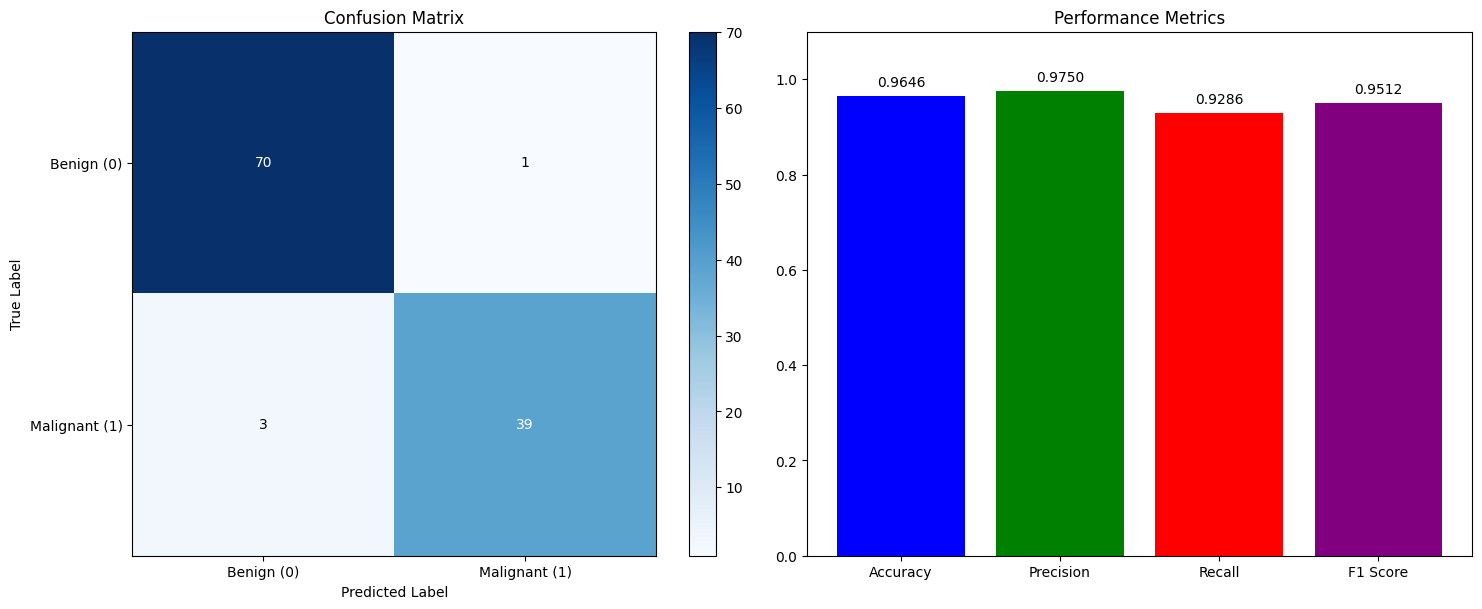

In [5]:
# 5. Visualization
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Confusion Matrix Plot
cm = np.array([[tn, fp], [fn, tp]])
im = ax[0].imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax[0].set_title('Confusion Matrix')
plt.colorbar(im, ax=ax[0])
tick_marks = np.arange(2)
ax[0].set_xticks(tick_marks, ['Benign (0)', 'Malignant (1)'])
ax[0].set_yticks(tick_marks, ['Benign (0)', 'Malignant (1)'])
thresh = cm.max() / 2.
for i, j in np.ndindex(cm.shape):
    ax[0].text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
             color="white" if cm[i, j] > thresh else "black")
ax[0].set_ylabel('True Label')
ax[0].set_xlabel('Predicted Label')

# Performance Metrics Plot
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy, precision, recall, f1]
ax[1].bar(metrics, values, color=['blue', 'green', 'red', 'purple'])
ax[1].set_ylim(0, 1.1)
ax[1].set_title('Performance Metrics')
for i, v in enumerate(values):
    ax[1].text(i, v + 0.02, f"{v:.4f}", ha='center')

plt.tight_layout()
plt.show()